# 01 — Exploratory Data Analysis
Part of the *Kenya Household Food Security Classification* capstone project.

This notebook loads the raw Wave 4 survey extracts, builds the food-security
target (FISS), and explores it against household characteristics.

**Input:** `data/raw/w4_hh.csv`, `data/raw/w4_adult.csv`
**Output:** `data/processed/01_df.pkl` (consumed by `02_preprocessing.ipynb`)


# Kenya Household Food Security Classification — Capstone Project (v2)

**Problem Statement:** Using Wave 4 of the Kenya COVID-19 Rapid Response Phone Survey
(World Bank/KNBS/UC Berkeley, ~4,894 households, Jan–Mar 2021), predict a household's
food security status based on household demographics, housing, livelihoods, coping
behavior, and social-protection characteristics, measured by **weighted F1** (primary)
and **macro F1** (secondary), disaggregated by urban/rural location and county.

**Track:** Classification &nbsp;|&nbsp; **Dataset:** FAO Microdata Catalogue #2344 &nbsp;|&nbsp;
**Target population:** Kenyan households, Wave 4


1. **Target construction follows an established food-security scoring methodology**
   instead of an ad-hoc sum. The six/seven `s5_...` experience questions are recoded and
   combined the way  FANTA's (Food and Nutrition Technical Assistance) **HFIAS** (Household Food Insecurity Access Scale) and WFP's
   **CARI** (Consolidated Approach for Reporting Indicators of Food Security) combine
   raw survey responses into an ordinal severity scale — see Section 3 for the full
   methodology and its limitations given what this survey actually asked.
2. A second, independent score modeled on the **Household Hunger Scale (HHS)** is
   computed purely as a validation check on the primary target .
3. The feature set is substantially expanded per the food-security column review:
   household head education, asset ownership, farming/livestock activity, enterprise activity, transfers
   received, food-expenditure share, distress-coping flags (asset sales, loans), health
   access, and migration — each cross-checked against Wave 4 for actual availability
   rather than assumed from the codebook.
4. Fields confirmed structurally unavailable at Wave 4 (toilet type, water source, room
   count, the `s6_copingactions_*` battery — all Wave 5+ only) are still included as
   *candidates* so the missingness screen demonstrably drops them, rather than being
   silently excluded.

## 1. Import the Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

## 2. Load and Inspect

Both files supplied here (`w4_hh.csv`, `w4_adult.csv`) are already filtered to Wave 4,
so no wave filter is needed — but we still check the `wave` column defensively in case
that assumption is ever wrong for a re-run with the full panel files.

In [22]:
# NOTE ON DATA: w4_hh.csv / w4_adult.csv come from the World Bank Microdata
# Library under a research-purposes-only license that does not permit
# redistribution. These files live in data/raw/ locally and are intentionally
# NOT committed to this repo (see .gitignore) download them yourself from
# the Microdata Library and place them there before running this notebook.


In [23]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
path = "/content/drive/MyDrive/Ngao Labs Program/Capstone Project"
# folder containing hh.csv and adult.csv (not tracked in git)

In [25]:
#load data
hh = pd.read_csv(path +'/hh.csv', low_memory=False)
adult = pd.read_csv(path +'/hh_adult.csv', low_memory=False)

print("hh.csv shape:", hh.shape)
print("hh_adult.csv shape:", adult.shape)
print("Wave values present in hh:", hh['wave'].unique())
print("Wave values present in adult:", adult['wave'].unique())


hh.csv shape: (40235, 2410)
hh_adult.csv shape: (96878, 346)
Wave values present in hh: [1 5 2 3 4 6 7 8]
Wave values present in adult: [1 5 2 3 4 6 7 8]


In [26]:
#load data
# Already filtered to Wave 4, but we check defensively in case this is ever
# re-run against the full, unfiltered panel files.
w4 = hh[hh['wave'] == 4].copy()
a4 = adult[adult['wave'] == 4].copy()
if 'wave' in w4.columns and w4['wave'].nunique() > 1:
    w4 = w4[w4['wave'] == 4].copy()
if 'wave' in a4.columns and a4['wave'].nunique() > 1:
    a4 = a4[a4['wave'] == 4].copy()

print("Wave 4 households:", w4.shape)
print("Wave 4 adult records:", a4.shape)


Wave 4 households: (4894, 2410)
Wave 4 adult records: (11483, 346)


In [27]:
# Aggregate adult-level records up to the household level.
# [NEW] beyond employment: average hours worked, whether any adult was laid off during
# COVID, and whether any adult is a migrant -- all plausible livelihoods/shock signals
# that were sitting in hh_adult.csv unused.
emp_agg = a4.groupby('hhid').agg(
    any_adult_employed=('employed', 'max'),
    hh_employment_rate=('employed', 'mean'),
    hh_avg_hours=('total_hours', 'mean'),
    any_adult_laidoff=('wholaidoff', 'max'),
).reset_index()

mig_agg = a4.groupby('hhid').agg(
    any_migrant=('migrant_status', 'max')
).reset_index()

# Household head education -- corrected from the previous round. The household-level
# field (s2_q29_hhheduc) is 100% missing at Wave 4; this per-adult field, filtered to
# the head of household, is only ~0.2% missing.
head_edu = (
    a4[a4['ishead'] == 1][['hhid', 'education_level']]
    .rename(columns={'education_level': 'head_education_level'})
)
assert head_edu['hhid'].duplicated().sum() == 0, "more than one head per household!"

df = (
    w4.merge(emp_agg, on='hhid', how='left')
      .merge(mig_agg, on='hhid', how='left')
      .merge(head_edu, on='hhid', how='left')
)
df['any_adult_employed'] = df['any_adult_employed'].fillna(0)
df['hh_employment_rate'] = df['hh_employment_rate'].fillna(0)
df['hh_avg_hours'] = df['hh_avg_hours'].fillna(0)
df['any_adult_laidoff'] = df['any_adult_laidoff'].fillna(0)
df['any_migrant'] = df['any_migrant'].fillna(0)

print("Merged household dataset shape:", df.shape)
print("head_education_level missing:", df['head_education_level'].isnull().mean() * 100, "%")
df[['hhid', 'urban', 'hhsize', 'head_gender', 'head_age', 'any_adult_employed', 'head_education_level']].head()

Merged household dataset shape: (4894, 2416)
head_education_level missing: 0.22476501838986515 %


,hhid,urban,hhsize,head_gender,head_age,any_adult_employed,head_education_level
0,3,1,3,1,56.0,1.0,2.0
1,4,1,11,0,44.0,1.0,2.0
2,5,1,5,0,35.0,1.0,2.0
3,6,0,2,0,42.0,0.0,4.0
4,7,1,2,0,32.0,0.0,4.0


## 3. Target Construction: A Standards-Based Food Security Score

### 3.1 Why not just sum the raw columns?

The six source columns behind the target are not on the same scale: `s5_q38_worryfood`
is a **yes/no** flag (0 or 1), while `s5_q39a_hungryadult`, `s5_q39b_hungrychild`,
`s5_q40a_skippedadult`, `s5_q40b_skippedchild`, `s5_q41a_nofoodadult`, and
`s5_q41b_nofoodchild` are **day-counts** (0–7, days in the recall period the behavior
occurred). Summing them raw effectively lets one household's "skipped a meal 7 days"
count seven times as much as another household's "worried about food," even though
worry and repeated full-day hunger are not equivalent in severity. That is a modeling
choice worth being explicit and principled about, so we replace it with something closer
to how the food-security literature actually scores these instruments.

### 3.2 Method: HFIAS-style occurrence/frequency recoding

FANTA's **HFIAS** scores each occurrence question 0–3 by how *often* it happened
(0 = never, 1 = rarely, 2 = sometimes, 3 = often), then sums across items into a single
household **Food Insecurity Access Scale score**, and WFP's **CARI** (Consolidated Approach for Reporting Indicators) approach uses
exactly this kind of severity score to sort households into ordered food-security
categories. This survey didn't ask the full canonical 9-item HFIAS battery (no
diet-quality items- eating less-preferred foods, limited variety, etc.), but the six
day-count/occurrence questions it does ask map onto HFIAS's core "insufficient food
intake" domain, plus one anxiety-domain item (worry). We recode on that basis:

- **Worry** (`s5_q38_worryfood`): already a 0/1 occurrence flag — kept as-is (weight 1,
  matching its status as the mildest indicator in HFIAS's anxiety domain).
- **The six day-count items**: recoded 0–3 using HFIAS's own frequency convention,
  adapted to this survey's 7-day recall window: 0 days → 0 (never), 1–2 days → 1
  (rarely), 3–4 days → 2 (sometimes), 5–7 days → 3 (often).

The sum of all seven recoded items is the household's **Food Insecurity Severity Score
(FISS)**, ranging 0–19.

### 3.3 From score to category (CARI-style)

WFP's CARI approach doesn't stop at a continuous score — it buckets households into
ordered food-security phases. We do the same, using the natural breakpoints in this
score's distribution (each recoded item can only contribute 0 in the food-secure case,
so FISS = 0 is a clean "no reported hardship" cutoff; FISS = 1 typically reflects worry
alone or a single rare occurrence; the remaining range splits into a moderate and a
severe band):

| FISS score | Category |
|---|---|
| 0 | `food_secure` |
| 1 | `mildly_insecure` |
| 2–3 | `moderately_insecure` |
| 4+ | `severely_insecure` |

This yields **four** ordered classes (vs. three previously) — closer to the standard
HFIAS/CARI convention of Food Secure / Mildly / Moderately / Severely Food Insecure.

In [28]:
food_cols = ['s5_q38_worryfood', 's5_q39a_hungryadult', 's5_q39b_hungrychild',
             's5_q40a_skippedadult', 's5_q40b_skippedchild',
             's5_q41a_nofoodadult', 's5_q41b_nofoodchild']

print("Missing values in food security source columns (Wave 4):")
print((df[food_cols].isnull().mean() * 100).round(2))

print("\nRaw value ranges (confirms worry is binary, the rest are day-counts):")
print(df[food_cols].describe().loc[['min', 'max']])

Missing values in food security source columns (Wave 4):
s5_q38_worryfood        0.0
s5_q39a_hungryadult     0.0
s5_q39b_hungrychild     0.0
s5_q40a_skippedadult    0.0
s5_q40b_skippedchild    0.0
s5_q41a_nofoodadult     0.0
s5_q41b_nofoodchild     0.0
dtype: float64

Raw value ranges (confirms worry is binary, the rest are day-counts):
     s5_q38_worryfood  s5_q39a_hungryadult  s5_q39b_hungrychild  \
min               0.0                  0.0                  0.0   
max               1.0                  7.0                  5.0   

     s5_q40a_skippedadult  s5_q40b_skippedchild  s5_q41a_nofoodadult  \
min                   0.0                   0.0                  0.0   
max                   7.0                   7.0                  7.0   

     s5_q41b_nofoodchild  
min                  0.0  
max                  3.0  


In [29]:
freq_cols = ['s5_q39a_hungryadult', 's5_q39b_hungrychild', 's5_q40a_skippedadult',
             's5_q40b_skippedchild', 's5_q41a_nofoodadult', 's5_q41b_nofoodchild']

def recode_freq(v):
    """HFIAS-style frequency recoding, adapted to a 7-day recall window."""
    if pd.isna(v):
        return np.nan
    if v == 0:
        return 0        # never
    elif v <= 2:
        return 1         # rarely
    elif v <= 4:
        return 2         # sometimes
    else:
        return 3         # often

for c in freq_cols:
    df[c + '_sev'] = df[c].apply(recode_freq)

sev_cols = [c + '_sev' for c in freq_cols]

# Food Insecurity Severity Score (FISS): worry (0/1) + six recoded 0-3 items -> 0-19
df['fiss'] = df['s5_q38_worryfood'].fillna(0) + df[sev_cols].sum(axis=1)

print("FISS distribution:")
print(df['fiss'].value_counts().sort_index())
print("\nFISS summary stats:")
print(df['fiss'].describe())

FISS distribution:
fiss
0     2445
1     1187
2      293
3      354
4      232
5      129
6       71
7      125
8       18
9       15
10       5
11       9
12       3
13       6
14       1
17       1
Name: count, dtype: int64

FISS summary stats:
count    4894.000000
mean        1.283613
std         1.969850
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: fiss, dtype: float64


In [30]:
def bucket_fiss(score):
    if score == 0:
        return 'food_secure'
    elif score == 1:
        return 'mildly_insecure'
    elif score <= 3:
        return 'moderately_insecure'
    else:
        return 'severely_insecure'

df['food_security_status'] = df['fiss'].apply(bucket_fiss)

order = ['food_secure', 'mildly_insecure', 'moderately_insecure', 'severely_insecure']
class_counts = df['food_security_status'].value_counts()[order]
class_props = df['food_security_status'].value_counts(normalize=True)[order]
print(class_counts)
print()
print((class_props * 100).round(1).astype(str) + '%')

food_security_status
food_secure            2445
mildly_insecure        1187
moderately_insecure     647
severely_insecure       615
Name: count, dtype: int64

food_security_status
food_secure            50.0%
mildly_insecure        24.3%
moderately_insecure    13.2%
severely_insecure      12.6%
Name: proportion, dtype: object


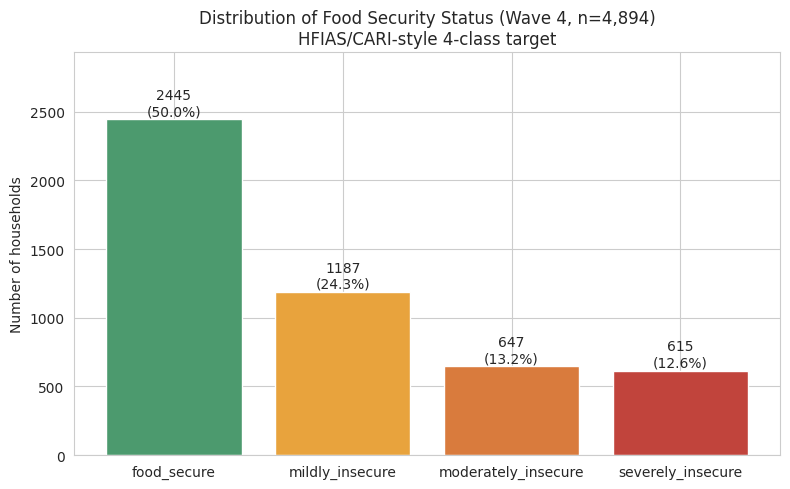

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C9A6E', '#E8A33D', '#D97B3D', '#C1443C']
bars = ax.bar(order, [class_counts[c] for c in order], color=colors)
for bar, c in zip(bars, order):
    pct = class_props[c] * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{class_counts[c]}\n({pct:.1f}%)', ha='center', fontsize=10)
ax.set_title('Distribution of Food Security Status (Wave 4, n=4,894)\nHFIAS/CARI-style 4-class target')
ax.set_ylabel('Number of households')
ax.set_ylim(0, class_counts.max() * 1.2)
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()

### 3.4 Validation: a second, independent hunger score

As a sanity check on the FISS/CARI target, we compute a score modeled on FANTA's
simpler **Household Hunger Scale (HHS)**, which uses just three quantity-of-food items
(no food in the house, going to sleep hungry, going a whole day and night without
eating) scored 0–2 by frequency and summed into a 0–6 scale. This survey doesn't have a
direct "no food in the house" item, so we approximate with the two items that most
directly correspond to HHS's hunger/no-food-all-day questions
(`s5_q39a_hungryadult`, `s5_q41a_nofoodadult`). If this independently-built score
correlates strongly with the primary target, that's evidence the primary target is
capturing a real, stable underlying construct rather than an artifact of our specific
recoding choices — it is **not** used as a model feature.

In [32]:
def hhs_recode(v):
    if pd.isna(v):
        return np.nan
    if v == 0:
        return 0
    elif v <= 2:
        return 1
    else:
        return 2

df['hhs_score'] = df['s5_q39a_hungryadult'].apply(hhs_recode) + df['s5_q41a_nofoodadult'].apply(hhs_recode)

corr = df['fiss'].corr(df['hhs_score'])
print(f"Correlation between FISS (primary target's score) and the independent HHS-style score: {corr:.3f}")
print("\nMean HHS-style score by FISS-derived category (should increase monotonically):")
print(df.groupby('food_security_status')['hhs_score'].mean()[order])

Correlation between FISS (primary target's score) and the independent HHS-style score: 0.757

Mean HHS-style score by FISS-derived category (should increase monotonically):
food_security_status
food_secure            0.000000
mildly_insecure        0.007582
moderately_insecure    0.205564
severely_insecure      1.200000
Name: hhs_score, dtype: float64


A correlation above 0.7 and a monotonically increasing mean HHS score across the four
FISS-derived categories both support treating `food_security_status` as a coherent,
validated target rather than an artifact of the specific recoding thresholds chosen
above.

**Leakage note:** `s53_q6_hunger` and `s53_q6_staple` (a second hunger/staple-access
module, available and 0% missing at Wave 4) measure essentially the same underlying
construct as the target and are excluded from the feature set for the same reason the
six `s5_...` source columns are- using them as predictors would leak the outcome.
`s5_q6a_hungerjan20` (a pre-COVID hunger recall) is likewise excluded as a feature here,
even though it could in principle support a "change in food security" framing; that is
a reasonable extension but changes the modeling problem and is left for future work.

## 4. Exploratory Data Analysis

### 4.1 Missing data across the expanded candidate pool

s2_numhabrms            100.000000
s2_drinkwatersrc        100.000000
s6_copingactions_2      100.000000
s6_copingactions_3      100.000000
s2_typetoilet           100.000000
s6_copingactions_1      100.000000
s7_q4a_value             99.387004
s7_q3a_value             97.691050
s4_q4_acres              94.503474
s7_q1a_value_ken         91.601962
s4_q9_livestockvalue     75.255415
s4_q12_num_ent           23.620760
s5_q3a_food               0.245198
head_education_level      0.224765
s2_q20_wallmat            0.040866
s5_q4_rent                0.040866
s2_q19_floormat           0.020433
s9_q11_medsoutstock       0.020433
head_age_3group           0.000000
head_gender               0.000000
hhsize                    0.000000
urban                     0.000000
head_age                  0.000000
s2_q9a_county             0.000000
strata                    0.000000
s6_q2_tookloan            0.000000
s6_q1_soldasset           0.000000
any_adult_employed        0.000000
hh_employment_rate  

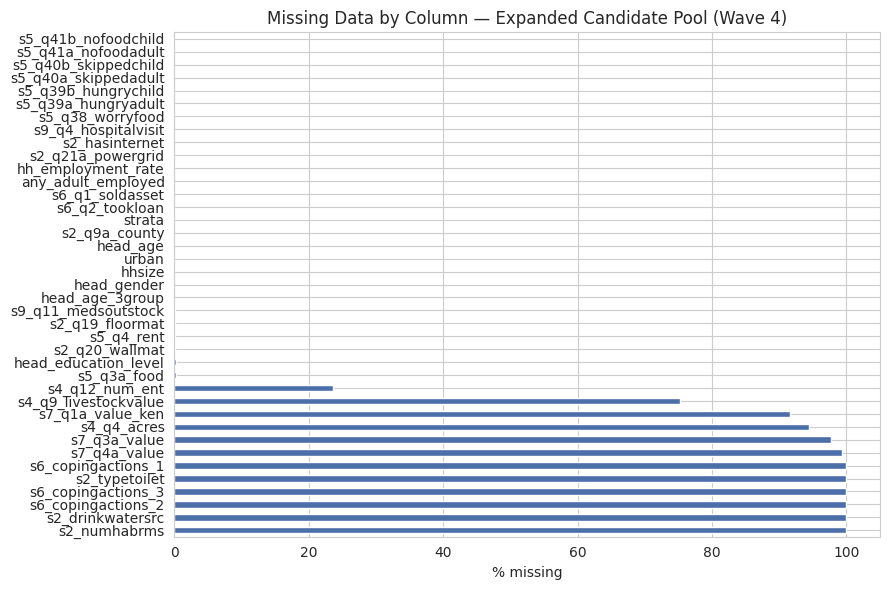

In [33]:
raw_candidate_check = [
    'urban', 'hhsize', 'head_gender', 'head_age', 'head_age_3group', 'strata',
    's2_q9a_county', 'any_adult_employed', 'hh_employment_rate', 'head_education_level',
    's2_q19_floormat', 's2_q20_wallmat', 's2_q21a_powergrid', 's2_hasinternet',
    's2_typetoilet', 's2_drinkwatersrc', 's2_numhabrms',            # expected to fail
    's6_copingactions_1', 's6_copingactions_2', 's6_copingactions_3',  # expected to fail
    's6_q1_soldasset', 's6_q2_tookloan',
    's4_q4_acres', 's4_q9_livestockvalue', 's4_q12_num_ent',
    's7_q1a_value_ken', 's7_q3a_value', 's7_q4a_value',
    's5_q3a_food', 's5_q4_rent',
    's9_q4_hospitalvisit', 's9_q11_medsoutstock',
] + food_cols

missing_pct = (df[raw_candidate_check].isnull().mean() * 100).sort_values(ascending=False)
print(missing_pct)

fig, ax = plt.subplots(figsize=(9, 6))
missing_pct.plot(kind='barh', ax=ax, color='#4C6EA9')
ax.set_title('Missing Data by Column — Expanded Candidate Pool (Wave 4)')
ax.set_xlabel('% missing')
plt.tight_layout()
plt.savefig('missing_data_barh.png')
plt.show()

`s2_typetoilet`, `s2_drinkwatersrc`, `s2_numhabrms`, and the full
`s6_copingactions_*` battery are 100% missing- confirmed structurally unavailable at
Wave 4 (collected from Wave 5 onward), not a data quality issue with this extract. They
will be formally screened out in Section 6, but two individual coping-relevant items
that *are* available at Wave 4- `s6_q1_soldasset` (asset sales) and `s6_q2_tookloan`
(borrowing)- survive and are kept as distress-coping proxies.

### 4.2 Distributions of key numeric features

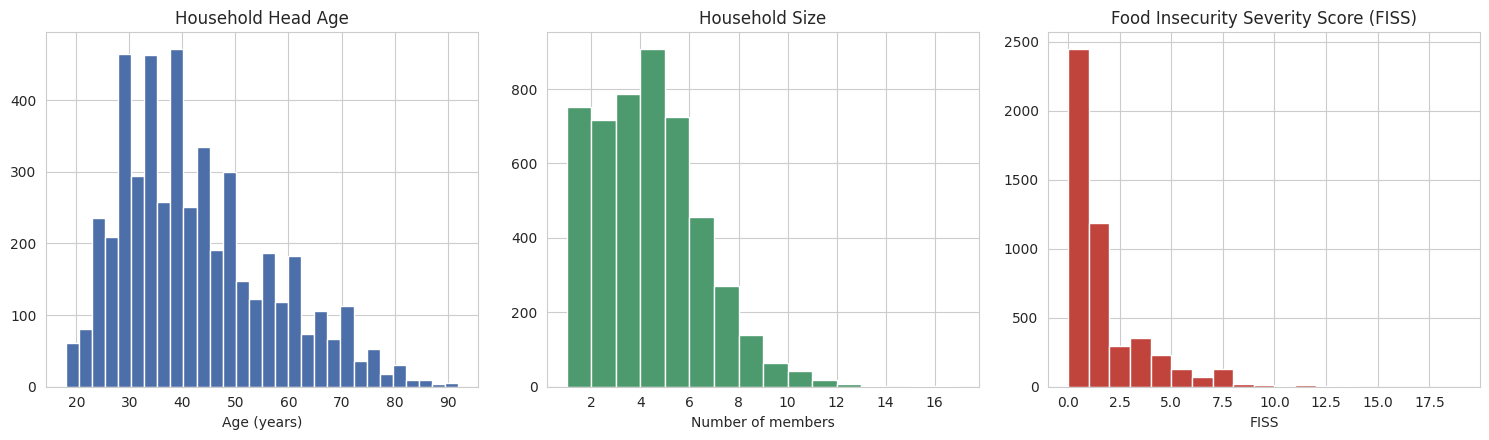

          head_age       hhsize         fiss
count  4894.000000  4894.000000  4894.000000
mean     42.715774     3.869228     1.283613
std      14.089156     2.156948     1.969850
min      18.000000     1.000000     0.000000
25%      32.000000     2.000000     0.000000
50%      40.000000     4.000000     1.000000
75%      51.000000     5.000000     2.000000
max      92.000000    17.000000    17.000000


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(df['head_age'], bins=30, color='#4C6EA9', edgecolor='white')
axes[0].set_title('Household Head Age')
axes[0].set_xlabel('Age (years)')

axes[1].hist(df['hhsize'], bins=range(1, 18), color='#4C9A6E', edgecolor='white')
axes[1].set_title('Household Size')
axes[1].set_xlabel('Number of members')

axes[2].hist(df['fiss'], bins=range(0, 20), color='#C1443C', edgecolor='white')
axes[2].set_title('Food Insecurity Severity Score (FISS)')
axes[2].set_xlabel('FISS')
plt.tight_layout()
plt.savefig('numerical_distributions.png')
plt.show()

print(df[['head_age', 'hhsize', 'fiss']].describe())

### 4.3 What correlates with the target?

It is focused on understanding the relationships between different features (variables) in the dataset and the target variable, which is 'food_security_status'. In this part of the analysis, the goal is to identify which characteristics of a household are associated with its food security status.

This notebook uses two main methods to explore these correlations:

* **Cross-tabulation and Bar Plot for Categorical Features (Urban/Rural)**: The code creates a cross-tabulation (pd.crosstab) between the 'urban' (urban vs. rural) feature and 'food_security_status'. This shows the proportion of households in each food security category for urban and rural areas. The bar plot visualizes these proportions, allowing for a quick visual comparison of food security levels across urban and rural locations.

* **Box Plot for Numeric Features (Household Employment Rate)**: For numeric features like 'hh_employment_rate', a box plot is used to show the distribution of this feature across each 'food_security_status' category. This helps in understanding if, for example, a lower employment rate is generally associated with a higher level of food insecurity.

* **Correlation Heatmap for Numeric Features**: The numeric_for_corr.corr() line calculates the Pearson correlation coefficient between several numeric features and the 'fiss' (Food Insecurity Severity Score), which is the numerical basis for the 'food_security_status' target. A heatmap then visually displays these correlation coefficients. Positive correlations mean that as one variable increases, the other tends to increase, while negative correlations mean they tend to move in opposite directions. For example, a positive correlation between 'hhsize' and 'fiss' would suggest that larger households tend to have higher food insecurity severity scores.

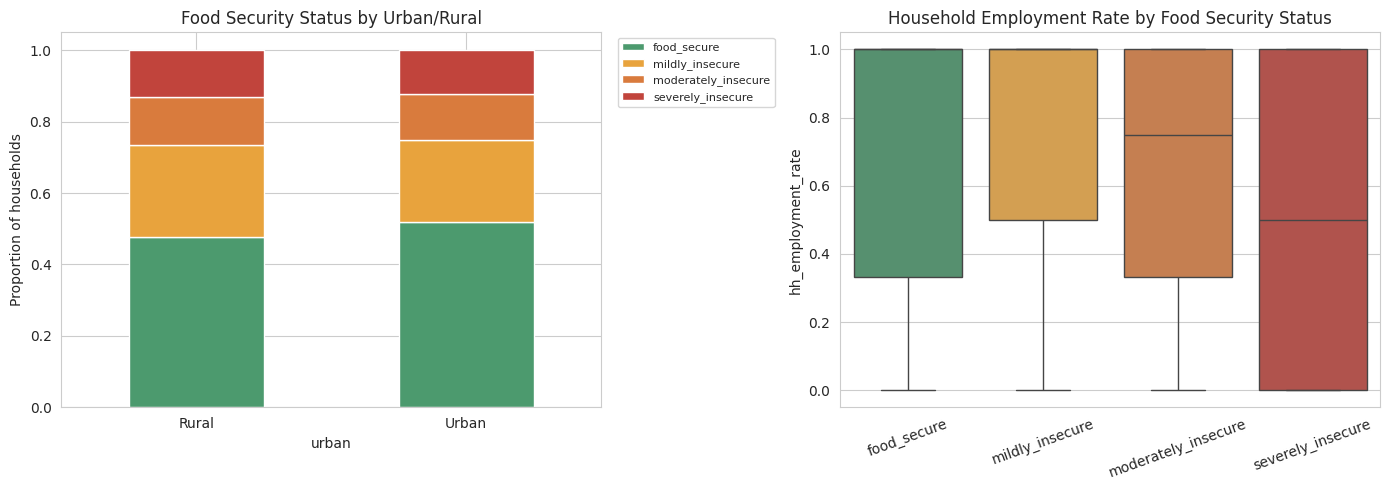

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct = pd.crosstab(df['urban'].map({0: 'Rural', 1: 'Urban'}), df['food_security_status'], normalize='index')
ct = ct[order]
ct.plot(kind='bar', stacked=True, ax=axes[0], color=colors)
axes[0].set_title('Food Security Status by Urban/Rural')
axes[0].set_ylabel('Proportion of households')
axes[0].legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df, x='food_security_status', y='hh_employment_rate', order=order, ax=axes[1],
            palette=colors)
axes[1].set_title('Household Employment Rate by Food Security Status')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('feature_target_relationships.png')
plt.show()

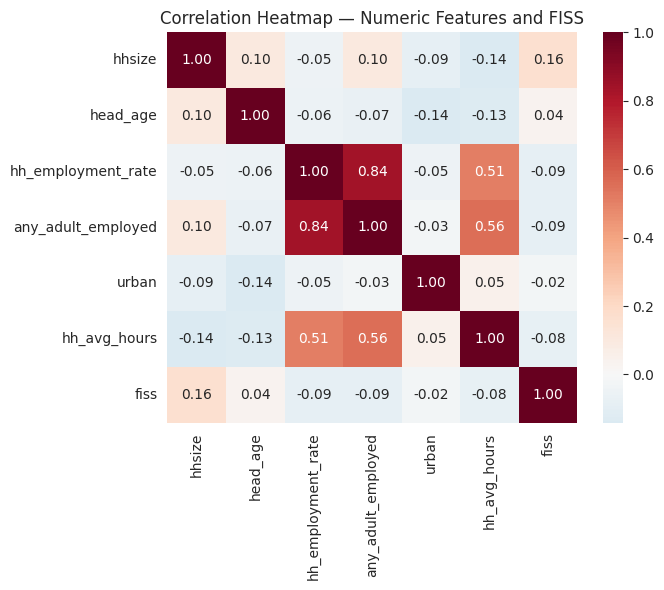

In [36]:
numeric_for_corr = df[['hhsize', 'head_age', 'hh_employment_rate', 'any_adult_employed',
                        'urban', 'hh_avg_hours', 'fiss']]
corr = numeric_for_corr.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features and FISS')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

### 4.4 Geographic pattern (by county)

Counties with highest average FISS (top 10 county codes):
s2_q9a_county
4     2.032258
11    2.030303
23    1.928571
25    1.916667
3     1.774194
40    1.726562
42    1.696970
7     1.642857
44    1.628571
10    1.610169
Name: fiss, dtype: float64

Counties with lowest average FISS (bottom 10 county codes):
s2_q9a_county
17    1.118182
13    1.088889
47    1.075862
32    1.063953
18    1.035088
46    0.964286
29    0.954023
26    0.896226
35    0.757009
19    0.684211
Name: fiss, dtype: float64


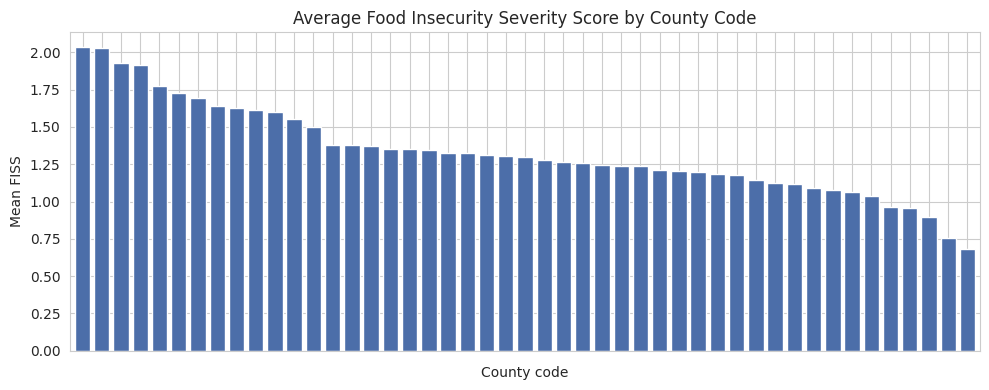

In [37]:
county_summary = df.groupby('s2_q9a_county')['fiss'].mean().sort_values(ascending=False)
print("Counties with highest average FISS (top 10 county codes):")
print(county_summary.head(10))
print("\nCounties with lowest average FISS (bottom 10 county codes):")
print(county_summary.tail(10))

fig, ax = plt.subplots(figsize=(10, 4))
county_summary.plot(kind='bar', ax=ax, color='#4C6EA9', width=0.8)
ax.set_title('Average Food Insecurity Severity Score by County Code')
ax.set_xlabel('County code')
ax.set_ylabel('Mean FISS')
ax.set_xticklabels([])
plt.tight_layout()
plt.savefig('county_severity.png')
plt.show()

### 4.5 Data quality checks

In [38]:
print("Duplicate hhid rows:", df['hhid'].duplicated().sum())
print("Households with age < 18 or > 100:", ((df['head_age'] < 18) | (df['head_age'] > 100)).sum())
print("Households with hhsize <= 0:", (df['hhsize'] <= 0).sum())

Duplicate hhid rows: 0
Households with age < 18 or > 100: 0
Households with hhsize <= 0: 0


No duplicate households and no impossible ages or household sizes.

## 13. Save Output for the Next Notebook

In [42]:
import pickle, os

# Ensure the path variable from cell 10D2UIFnl6DK is available
# If running this cell independently, uncomment and define path:
# path = "/content/drive/MyDrive/Ngao Labs Program/Capstone Project"

os.makedirs(path + '/data/processed', exist_ok=True)
with open(path + '/data/processed/01_df.pkl', 'wb') as f:
    pickle.dump({'df': df}, f)
print(f'Saved df {df.shape} to {path}/data/processed/01_df.pkl')

Saved df (4894, 2425) to /content/drive/MyDrive/Ngao Labs Program/Capstone Project/data/processed/01_df.pkl
